# Import data

In [1]:
import pandas as pd

from analyze_src.basic_data_inspection import DataInspector, DataTypesInspectionStrategy, SummaryStatisticsInspectionStrategy
from analyze_src.missing_values_analysis import SimpleMissingValuesAnalysis
from analyze_src.univariate_analysis import UnivariateAnalyzer, NumericalUnivariateAnalysis, CategoricalUnivariateAnalysis
from analyze_src.bivariate_analysis import BivariateAnalyzer, NumericalVsNumericalAnalysis, CategoricalVsNumericalAnalysis, CategoricalVsCategoricalAnalysis
from analyze_src.multivariate_analysis import SimpleMultivariateAnalysis

# Load Data

In [2]:
data_path = "../extracted_data/updated_ckd_dataset_with_stages.csv"
df= pd.read_csv(data_path)
df.head()

,serum_creatinine,gfr,bun,serum_calcium,ana,c3_c4,hematuria,oxalate_levels,urine_ph,blood_pressure,...,smoking,alcohol,painkiller_usage,family_history,weight_changes,stress_level,months,cluster,ckd_pred,ckd_stage
0,0.683683,32.946784,7.553739,10.039896,0,138.204989,0,2.878164,7.864308,115.224217,...,yes,daily,no,yes,stable,low,10,5,CKD,3
1,3.809044,32.685035,141.347494,8.330543,1,24.282343,1,4.767639,4.920015,130.143900,...,yes,daily,no,yes,loss,moderate,1,2,CKD,3
2,1.143827,2.079805,15.979104,9.419229,0,163.970666,0,1.818613,6.188115,98.026072,...,no,daily,no,no,stable,moderate,4,6,CKD,5
3,4.804657,109.871407,53.307333,7.556631,1,71.056846,1,4.051686,5.278607,142.166650,...,no,never,yes,yes,stable,high,9,2,CKD,1
4,4.920235,42.214590,134.182157,7.289379,1,23.384639,1,3.240920,4.862923,151.962572,...,no,occasionally,yes,no,gain,high,7,2,CKD,3


# Step 1: Basic Data Inspection

## info()

In [3]:
data_inspector= DataInspector(DataTypesInspectionStrategy())
data_inspector.execute_inspection(df)


 Data Types & Non-null Counts: 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   serum_creatinine   4000 non-null   float64
 1   gfr                4000 non-null   float64
 2   bun                4000 non-null   float64
 3   serum_calcium      4000 non-null   float64
 4   ana                4000 non-null   int64  
 5   c3_c4              4000 non-null   float64
 6   hematuria          4000 non-null   int64  
 7   oxalate_levels     4000 non-null   float64
 8   urine_ph           4000 non-null   float64
 9   blood_pressure     4000 non-null   float64
 10  physical_activity  4000 non-null   object 
 11  diet               4000 non-null   object 
 12  water_intake       4000 non-null   float64
 13  smoking            4000 non-null   object 
 14  alcohol            4000 non-null   object 
 15  painkiller_usage   4000 non-null   obj

## describe()

In [4]:
data_inspector.set_strategy(SummaryStatisticsInspectionStrategy())
data_inspector.execute_inspection(df)


 Summary Statistics (Numerical Features): 

       serum_creatinine          gfr          bun  serum_calcium          ana  \
count       4000.000000  4000.000000  4000.000000    4000.000000  4000.000000   
mean           1.551423    51.735449    39.346088       8.537530     0.300000   
std            1.217478    34.389322    42.495106       1.403631     0.458315   
min            0.500273     0.021317     7.000920       5.002407     0.000000   
25%            0.758924    20.263808    11.632573       7.810761     0.000000   
50%            0.995209    50.054933    16.296667       8.982200     0.000000   
75%            2.065796    80.258482    67.090486       9.583627     1.000000   
max            4.994009   119.923482   149.999395      10.199344     1.000000   

             c3_c4    hematuria  oxalate_levels     urine_ph  blood_pressure  \
count  4000.000000  4000.000000     4000.000000  4000.000000     4000.000000   
mean    109.757723     0.300000        2.624439     6.394566     

# Step 2: Missing Values Analysis


Missing Values Count by Column:
Series([], dtype: int64)

Visualizing Missing Values...


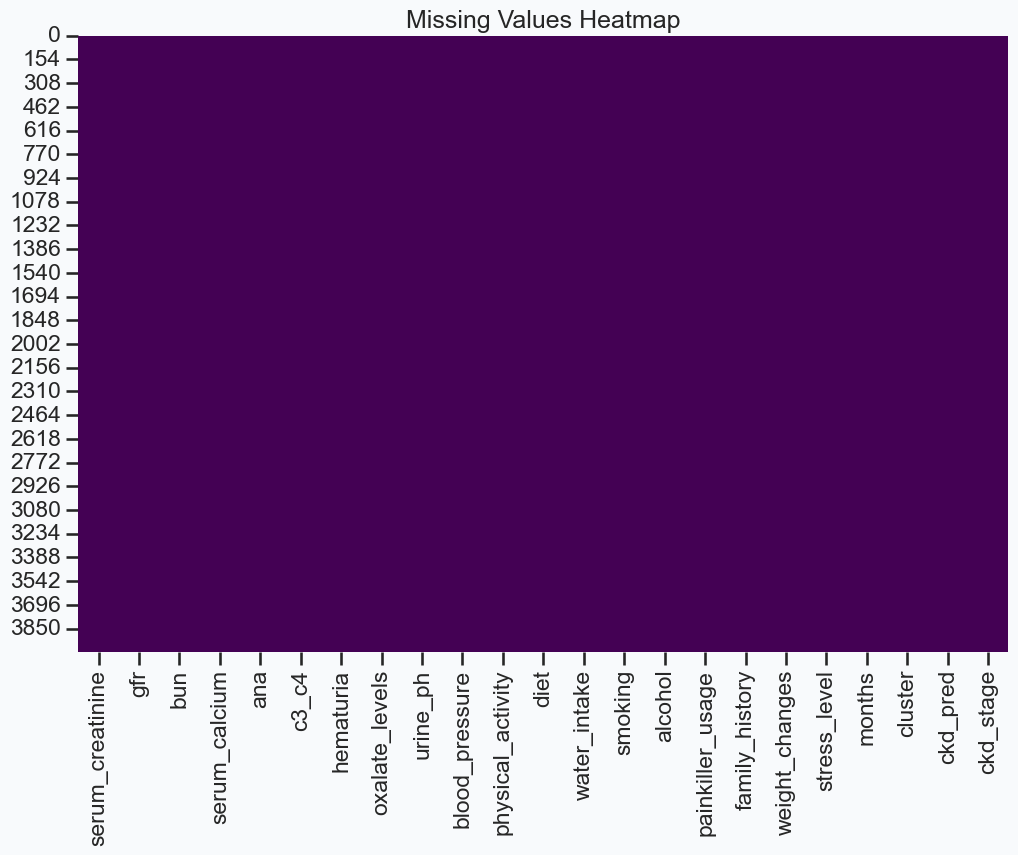

In [5]:
missing_value_analysis= SimpleMissingValuesAnalysis()
missing_value_analysis.analyze(df)

# Step 3: Univariate Analysis

## Numerical

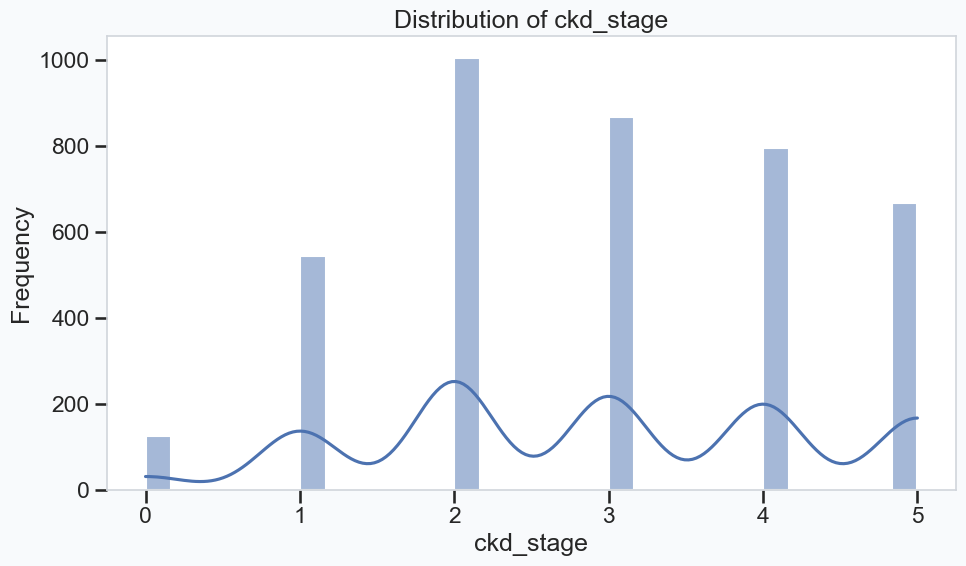

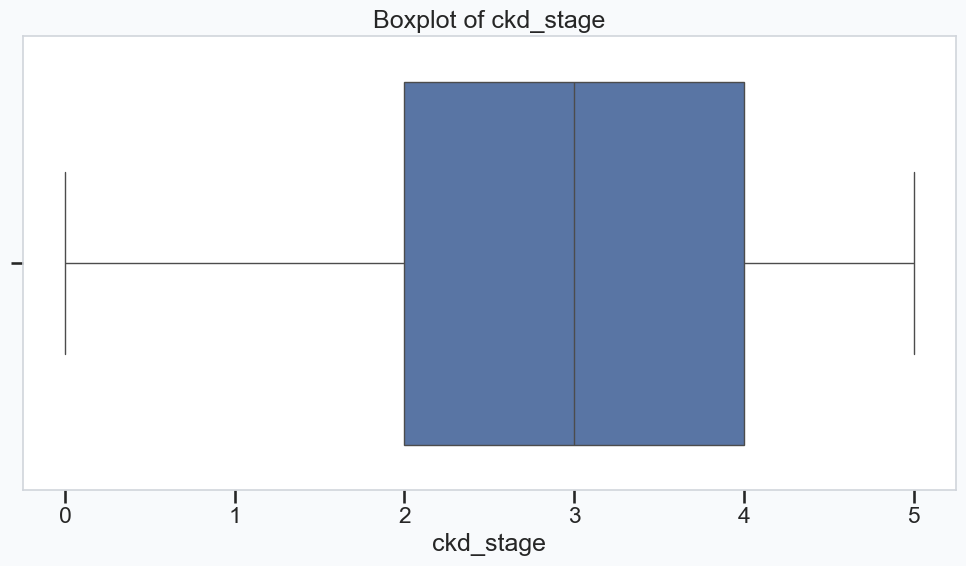

In [6]:
univariate_analysis= UnivariateAnalyzer(NumericalUnivariateAnalysis())
univariate_analysis.execute_analysis(df, 'ckd_stage')

## Categorical

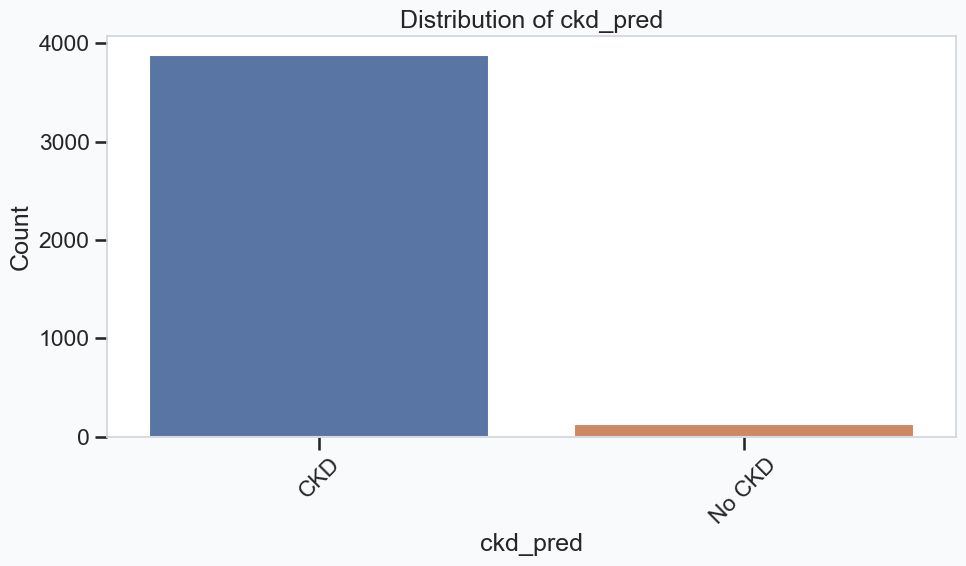

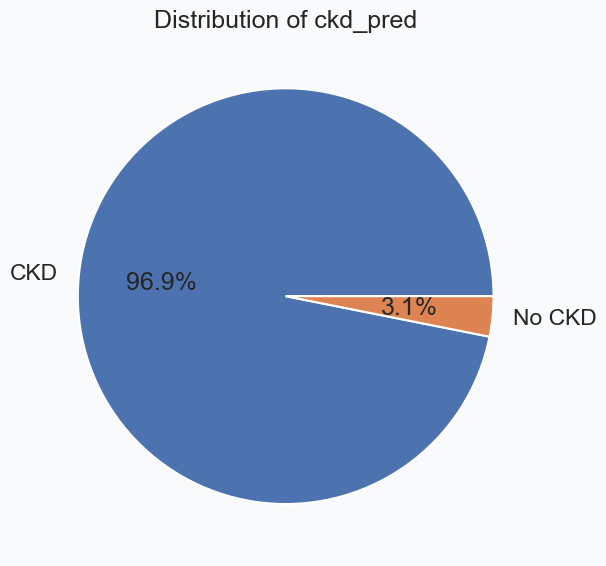

In [7]:
univariate_analysis.set_strategy(CategoricalUnivariateAnalysis())
univariate_analysis.execute_analysis(df, 'ckd_pred')

# Step 4: Bivariate Analysis

## Numerical VS Numerical

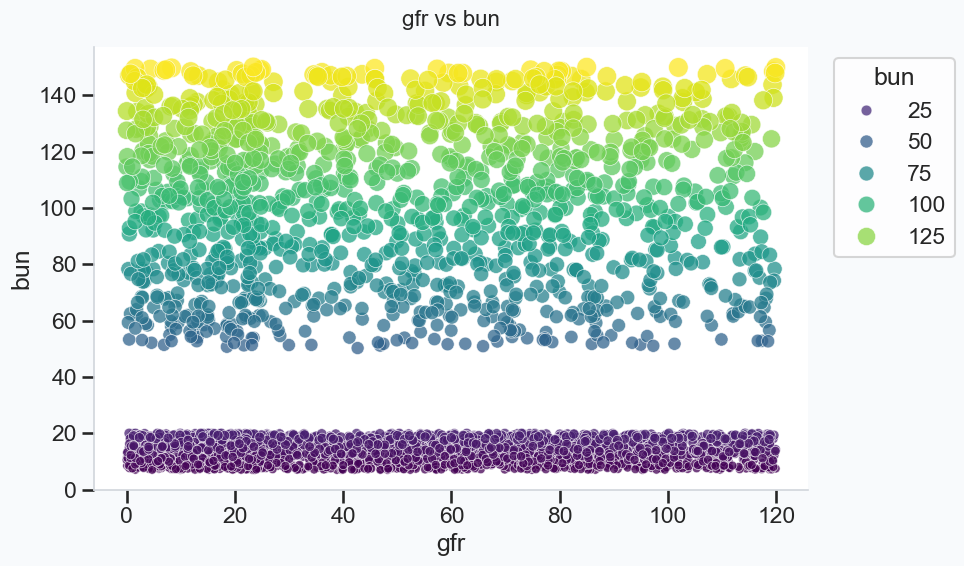

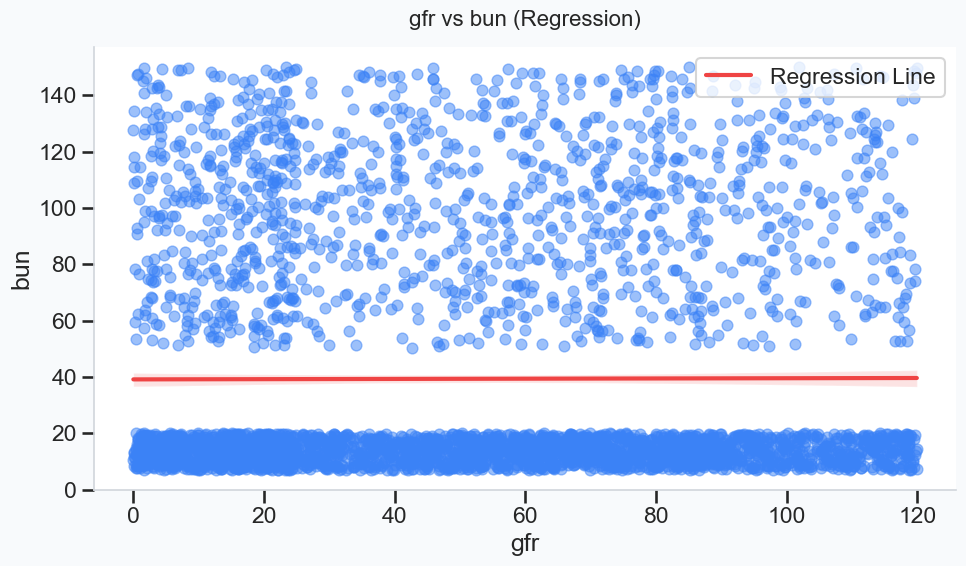

In [8]:
bivariate_analysis= BivariateAnalyzer(NumericalVsNumericalAnalysis())
bivariate_analysis.execute_analysis(df, 'gfr', 'bun')

## Categorical VS Numerical

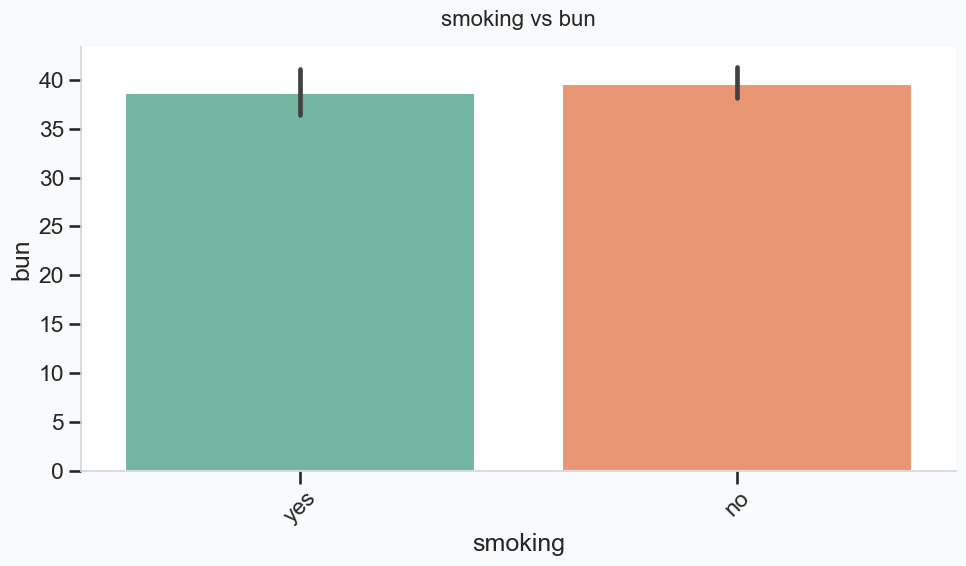

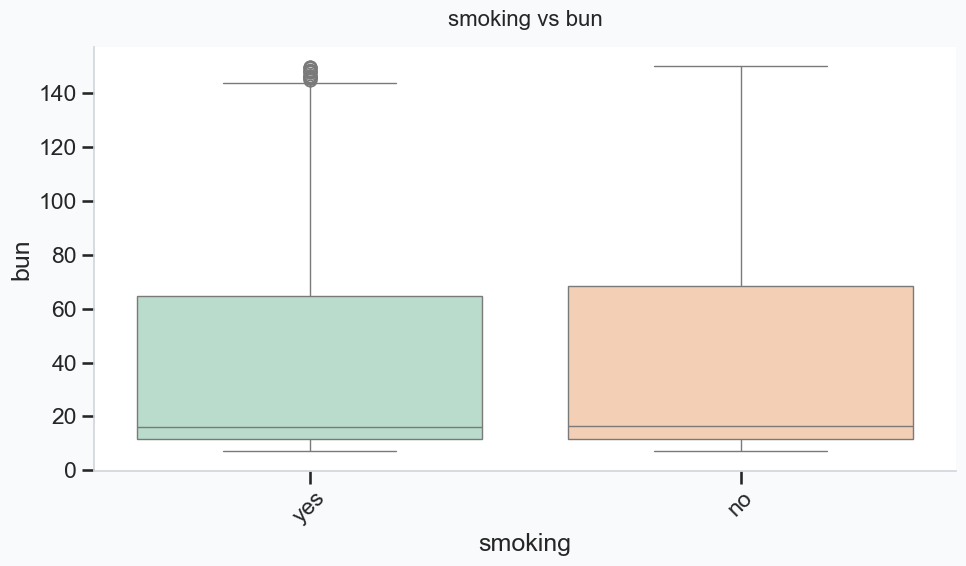

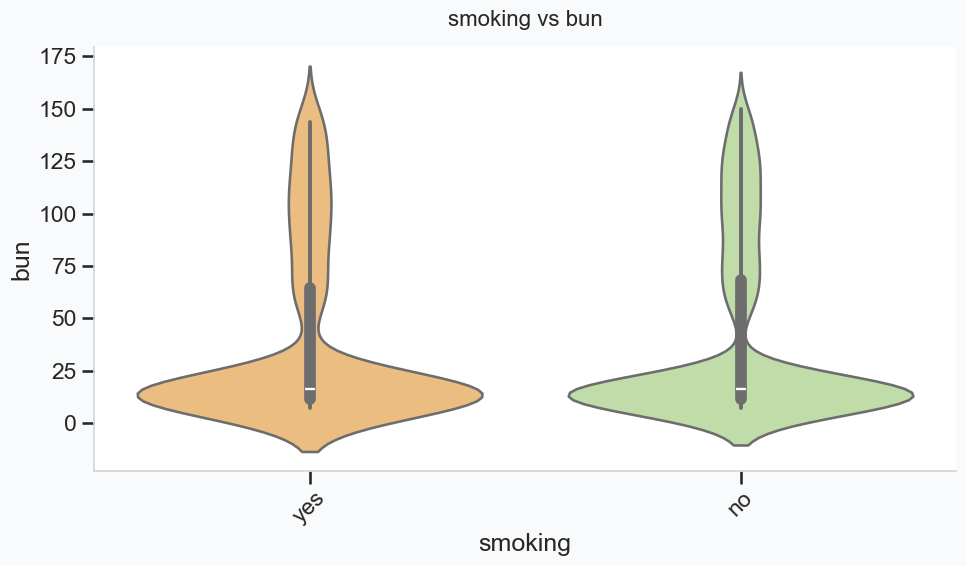

In [9]:
bivariate_analysis.set_strategy(CategoricalVsNumericalAnalysis())
bivariate_analysis.execute_analysis(df, "smoking", "bun")

## Categorical VS Categorical

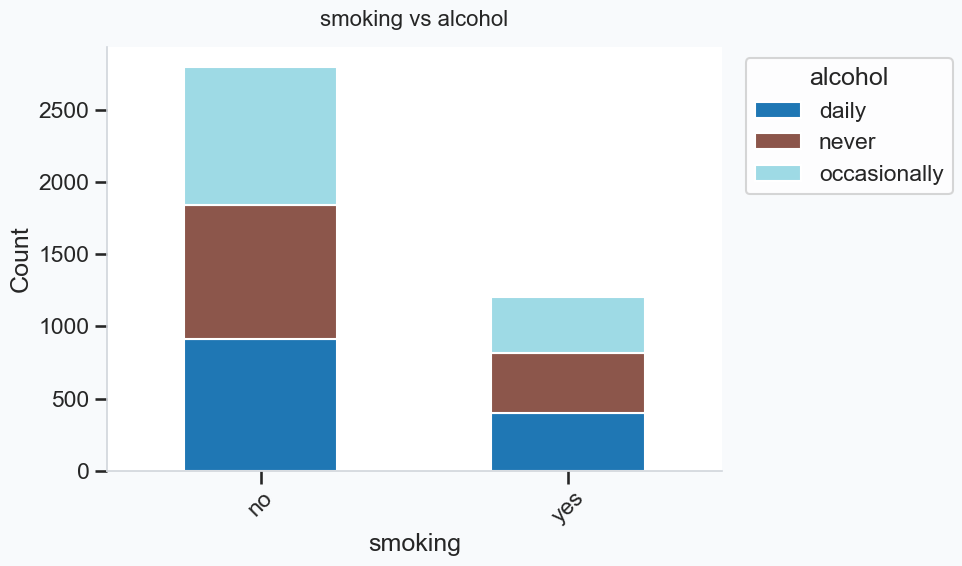

In [10]:
bivariate_analysis.set_strategy(CategoricalVsCategoricalAnalysis())
bivariate_analysis.execute_analysis(df, "smoking", "alcohol")

# Multivariate Analysis

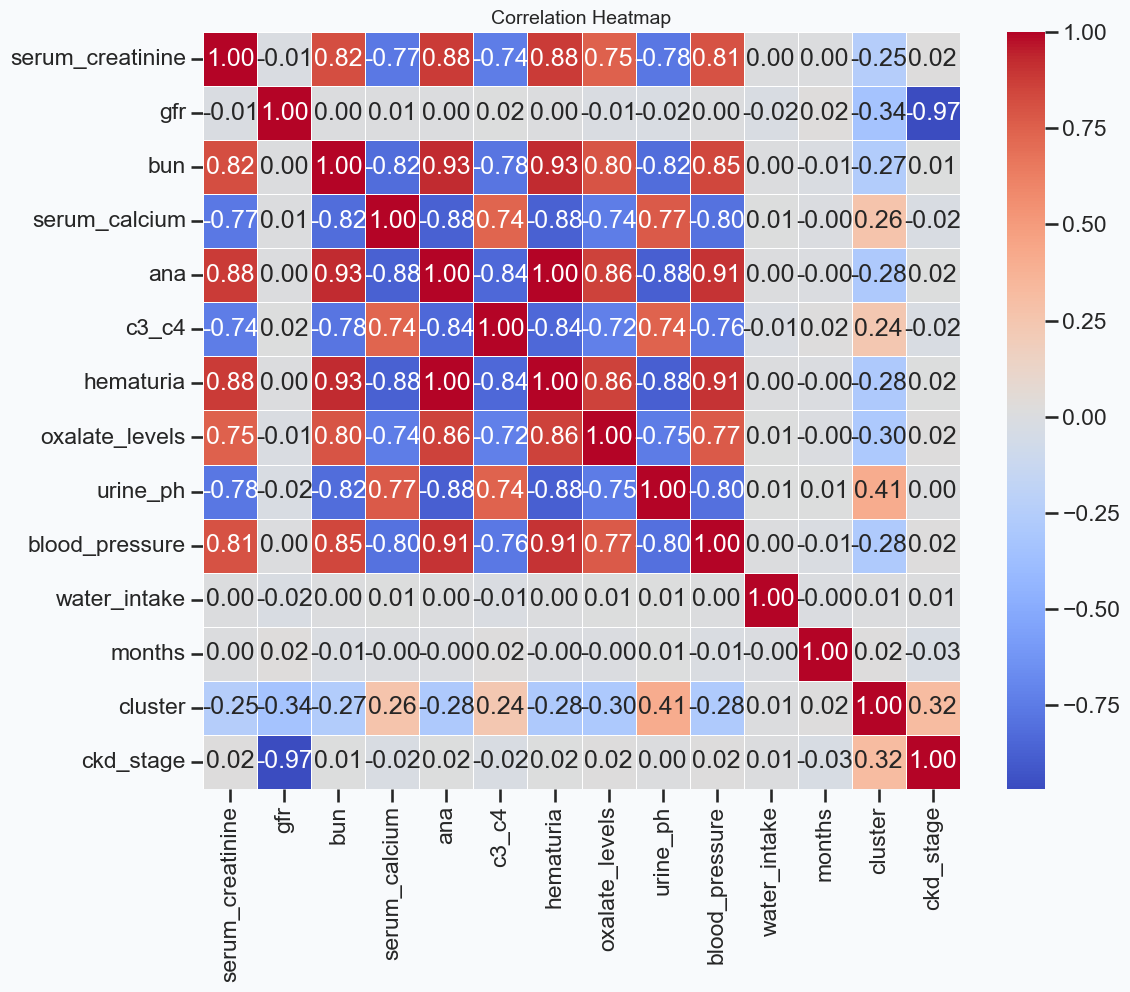

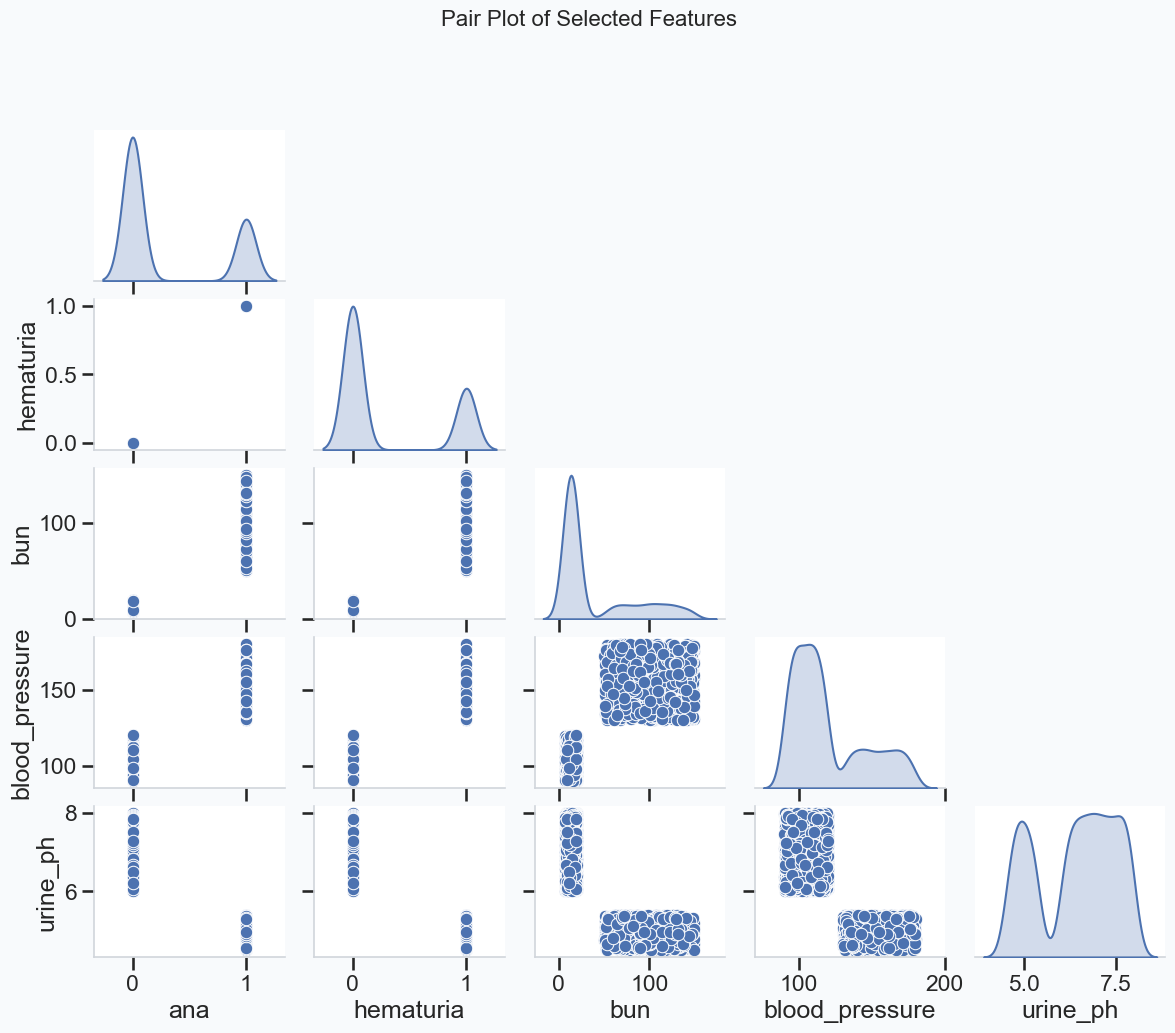

In [11]:
multivariate_analyzer = SimpleMultivariateAnalysis()
numeric_data= df[df.select_dtypes(include= "number").columns]


multivariate_analyzer.analyze(numeric_data)